#### 1. Download and load the Student Performance dataset.

In [2]:
import pandas as pd

data = pd.read_csv("student\student-mat.csv", sep=";")


**Data Exploration**

In [3]:
print("Shape:", data.shape)

data.head()

Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

#### 2. Perform data preprocessing, including handling missing values (if any), encoding categorical variables, and feature scaling.

**Check for missing values**

In [5]:
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


This dataset has no missing values

**Check for duplicates**

In [6]:
print("\nDuplicate Rows:", data.duplicated().sum())


Duplicate Rows: 0


This dataset has no duplicate values

**Identify Numerical and Categorical Features**

In [7]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3'],
      dtype='object')

Categorical Columns:
Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')


**Encode the Categorical Variables**

In [8]:
data_encoded = pd.get_dummies(
    data,
    columns=cat_cols,
    drop_first=True
)

In [9]:
print("Shape after encoding:", data_encoded.shape)

data_encoded.head()

Shape after encoding: (395, 42)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


Since this is Linear Regression, the model cannot work directly with text values.

We'll use One-Hot Encoding because:
* Most categorical variables are nominal (e.g., school, Mjob, reason, guardian), where there is no natural order.
* Label Encoding would assign numbers (e.g., school: GP=0, MS=1), which incorrectly suggests an order and can mislead a regression model.

#### 3. Select appropriate input features and the target variable.

In [38]:
X = data_encoded.drop("G3", axis=1)
y = data_encoded["G3"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (395, 41)
Target Shape: (395,)


**Check the target distribution**

In [11]:
print(y.describe())

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64


In [14]:
y.shape

(395,)

#### 4. Split the dataset into training and testing sets.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Since Gradient Descent updates weights based on feature values, all features should be on a similar scale. Otherwise, features with large values (e.g., absences) can dominate the updates and make convergence slow or unstable.**

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (316, 41)
Testing Set : (79, 41)


#### 5. Implement Linear Regression using the Gradient Descent algorithm.

**Initialize weights and bias**

In [18]:
import numpy as np

# Number of training samples and features
m, n = X_train.shape

# Initialize weights and bias
weights = np.zeros(n)
bias = 0

print("Number of samples :", m)
print("Number of features:", n)

Number of samples : 316
Number of features: 41


**Set Hyperparameters**

In [19]:
learning_rate = 0.01
iterations = 1000

In [20]:
cost_history = []

**Gradient Descent**

In [21]:
for i in range(iterations):

    # Step 1: Make predictions
    y_pred = np.dot(X_train, weights) + bias

    # Step 2: Compute cost (Mean Squared Error)
    cost = (1 / (2 * m)) * np.sum((y_pred - y_train) ** 2)

    # Store cost for plotting later
    cost_history.append(cost)

    # Step 3: Compute gradients
    dw = (1 / m) * np.dot(X_train.T, (y_pred - y_train))
    db = (1 / m) * np.sum(y_pred - y_train)

    # Step 4: Update weights and bias
    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

In [22]:
print("Final Cost:", cost_history[-1])

print("\nFirst 5 Weights:")
print(weights[:5])

print("\nBias:")
print(bias)

Final Cost: 1.4302497326261974

First 5 Weights:
[-0.17125245  0.09641219 -0.19232464  0.02557056 -0.03693969]

Bias:
10.325503582973733


**Interpretation:**

* Cost: The cost is the error that Gradient Descent tries to minimize during training. Initially, the cost was about 64. After 1000 iterations, it became 1.43. This means the algorithm successfully learned weights that greatly reduced the prediction error.

* Bias: The bias (intercept) obtained after training is 10.3255. Since all features were standardized, a feature value of 0 corresponds to the mean value of that feature. Therefore, when all standardized feature values are zero (representing an average student), the model predicts a final grade of approximately 10.33. This value is very close to the actual mean of the target variable (G3 = 10.42), indicating that the model has learned a reasonable baseline prediction.


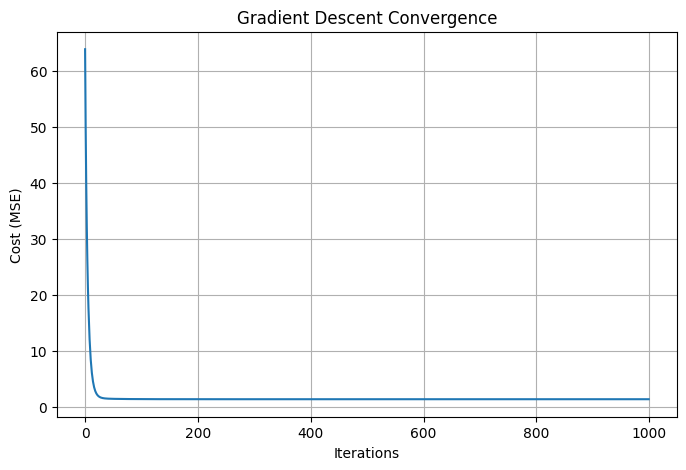

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(iterations), cost_history)

plt.title("Gradient Descent Convergence")
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.grid(True)

plt.show()

**Analysis of your graph**

* Initial Cost is High (~64) (Since all weights and bias started at 0, the initial predictions were poor. Therefore, the cost (MSE) was large.)
* Rapid Decrease in Cost (During the first 100–200 iterations, the cost decreases sharply. This indicates that Gradient Descent is learning quickly and moving towards the optimal solution.)
* Gradual Flattening (After around 300 iterations, the curve becomes almost horizontal. This means the model has nearly converged, and further weight updates produce only very small improvements.)


#### 6. Experiment with different learning rates and observe their effect on model convergence.


In [45]:
def gradient_descent(X_train, y_train, learning_rate, iterations):

    m, n = X_train.shape

    # Initialize weights and bias
    weights = np.zeros(n)
    bias = 0

    cost_history = []

    for i in range(iterations):

        # Predictions
        y_pred = np.dot(X_train, weights) + bias

        # Cost
        cost = (1 / (2 * m)) * np.sum((y_pred - y_train) ** 2)
        cost_history.append(cost)

        # Gradients
        dw = (1 / m) * np.dot(X_train.T, (y_pred - y_train))
        db = (1 / m) * np.sum(y_pred - y_train)

        # Update parameters
        weights = weights - learning_rate * dw
        bias = bias - learning_rate * db

    return weights, bias, cost_history

In [51]:
learning_rates = [0.001, 0.01, 0.1]

results = {}

for lr in learning_rates:

    weights, bias, cost_history = gradient_descent(
        X_train,
        y_train,
        learning_rate=lr,
        iterations=1000
    )

    results[lr] = cost_history

#### 7. Plot the loss (cost) versus the number of iterations.


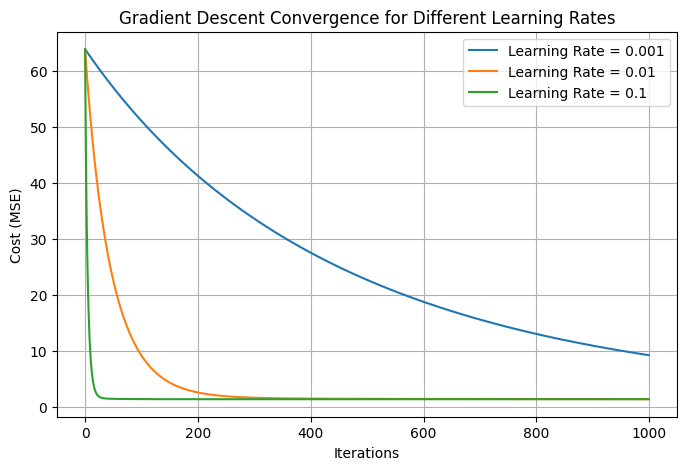

In [52]:
plt.figure(figsize=(8,5))

for lr in learning_rates:
    plt.plot(results[lr], label=f"Learning Rate = {lr}")

plt.title("Gradient Descent Convergence for Different Learning Rates")
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.legend()
plt.grid(True)

plt.show()

| Learning Rate | Convergence Speed | Final Cost | Observation                                   |
| ------------- | ----------------- | ---------: | --------------------------------------------- |
| **0.001**     | Slow              |         ~9 | Did not fully converge within 1000 iterations |
| **0.01**      | Moderate          |      ~1.43 | Stable and converged smoothly                 |
| **0.1**       | Fast              |      ~1.43 | Fastest convergence with stable behavior      |


**Interpretation**

The learning rate significantly affects the convergence of the Gradient Descent algorithm. A small learning rate (0.001) results in slow convergence and requires more iterations to reach the minimum cost. A moderate learning rate (0.01) provides stable and efficient convergence. A larger learning rate (0.1) converges much faster while remaining stable for this dataset, making it the best-performing learning rate among the three tested. None of the selected learning rates caused divergence or oscillation.

#### Evaluate the trained model using:
* #### Mean Absolute Error (MAE)
* #### Mean Squared Error (MSE)
* #### Root Mean Squared Error (RMSE)
* #### R² Score

**Train the Final Model (Best Learning Rate)**

In [27]:
best_lr = 0.1

weights, bias, cost_history = gradient_descent(
    X_train,
    y_train,
    learning_rate=best_lr,
    iterations=1000
)

**Make Predictions on the Test Set**

In [28]:
y_pred = np.dot(X_test, weights) + bias

**Evaluate the Model**

In [29]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.6466771735500207
Mean Squared Error (MSE): 5.656668049237072
Root Mean Squared Error (RMSE): 2.378375085901522
R² Score: 0.7241328939511099


#### 9. Interpret the results and comment on the convergence behavior and prediction performance of the model.

In [30]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,10,6.001689
1,12,11.528575
2,5,2.866432
3,10,8.796643
4,9,8.553167
5,13,11.889624
6,18,19.096823
7,6,7.173114
8,0,7.405055
9,14,12.311529


**Actual vs Precited Scatter Plot**

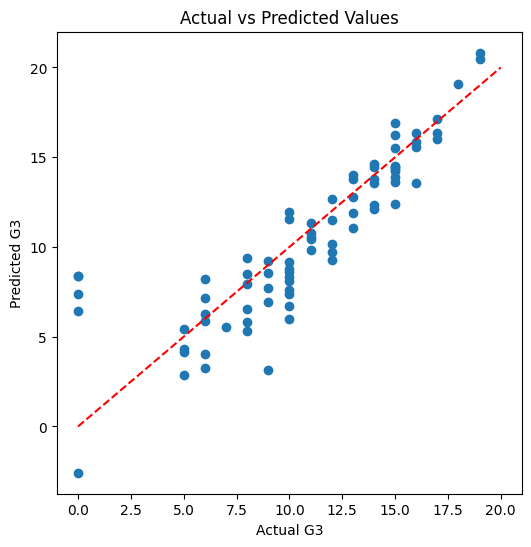

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted Values")

plt.plot([0,20],[0,20],'r--')

plt.show()

**Interpretation of the Actual vs Predicted Values Graph**

The graph compares the actual vs predicted final grades. The red dashed diagonal line (y = x) represents the ideal case where the predicted values are exactly equal to the actual values.

It can be observed that most of the data points are clustered close to the diagonal line, indicating that the model predicts the students' final grades with good accuracy.

A few points are far from the diagonal line, indicating larger prediction errors for those students. These deviations may be due to unusual student characteristics, noise in the data, or factors affecting academic performance that are not captured by the available features.

**Initial vs Final Cost**

In [34]:
print("Initial Cost:", cost_history[0])
print("Final Cost:", cost_history[-1])

Initial Cost: 63.814873417721515
Final Cost: 1.411527178568477


In [37]:
reduction = ((cost_history[0] - cost_history[-1]) / cost_history[0]) * 100

print(f"Cost reduced by {reduction:.2f}%")

Cost reduced by 97.79%
